In [ ]:
import pandas as pf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split

In [ ]:
df=keras.datasets.cifar10
(x_train,y_train),(x_test , y_test)=df.load_data()
x_train , x_test=x_train/255.0,x_test/255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
from keras import models
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation = 'relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

In [ ]:
from keras.src.ops import sparse_categorical_crossentropy
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:

datas=model.fit(x_train , y_train ,validation_split=0.1,epochs=5)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.4350 - loss: 1.5468 - val_accuracy: 0.5434 - val_loss: 1.2552
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.5744 - loss: 1.1901 - val_accuracy: 0.5948 - val_loss: 1.1260
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6312 - loss: 1.0517 - val_accuracy: 0.6610 - val_loss: 0.9838
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6693 - loss: 0.9491 - val_accuracy: 0.6838 - val_loss: 0.9207
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.6928 - loss: 0.8775 - val_accuracy: 0.6716 - val_loss: 0.9562


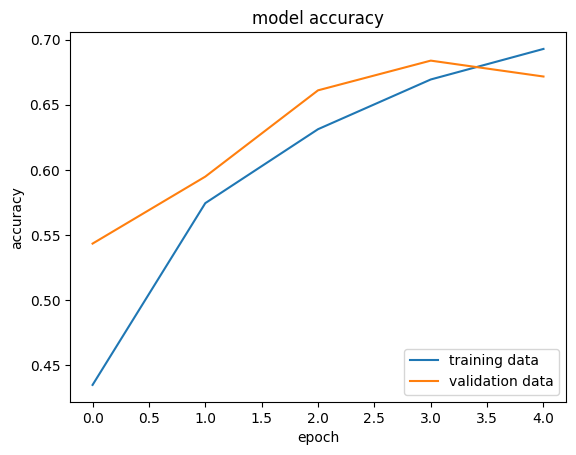

In [ ]:
plt.plot(datas.history['accuracy'])
plt.plot(datas.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='lower right')

Text(0.5, 1.0, 'Label: 4')

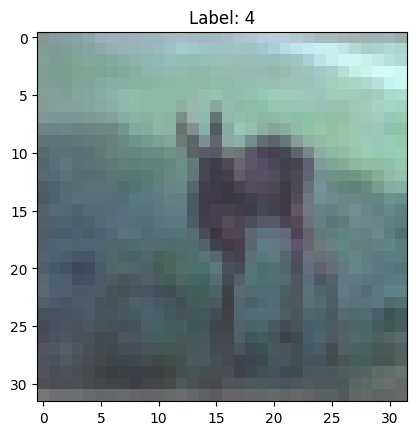

In [11]:
plt.imshow(x_test[555])
plt.title(f"Label: {y_test[555][0]}")